# Bolo: where should August's ₹1 crore go?

**Paid acquisition analysis for a subscription app · Python, pandas, matplotlib**

## The situation
Bolo is an Android app for practising spoken English, sold to Indian users. A ₹2 trial unlocks it for 24 hours; after that a paid plan starts automatically, either ₹249 a month or ₹1,499 a year (the plan is assigned at trial start). All users come from paid ads on three channels: josh, inmobi and glance, across six campaigns. All amounts are ex-GST.

Bolo's growth lead has to present the August paid-media plan on Monday. The budget is ₹1 crore, about 17% more than the recent monthly run rate, and it's currently split in rough proportion to past spend. The co-founder has noticed that some campaigns give very cheap trials, and wonders if cheap trials really mean cheap customers. Finance has also warned the budget could be cut to ₹60 lakh.

## Questions
1. Can we trust the data?
2. How does each campaign really perform, from install to paying user?
3. Do cheap trials always mean cheap paying users?
4. Should spend shift between weekdays and weekends?
5. How should ₹1 crore be split in August, and what happens if it's cut to ₹60 lakh?
6. Which one metric should the team steer on each week?

## Key insights
1. **The data had three problems, fixed before any analysis.** Two josh campaigns lost their trial tracking for 7 days (6–12 June): spend and installs were normal, but trials fell almost to zero. It was spotted on 13 June, when renewals were higher than the previous day's trials, which can't happen. Glance revenue for 15–21 July included 18% GST by mistake. Inmobi spend on 22 May was counted twice.
2. **Campaigns differ a lot in cost.** One paying user costs ₹270 on the best campaign and ₹1,177 on the worst, more than 4 times as much.
3. **Cheap trials don't always mean cheap customers.** `jo_retarget_signup` has cheap trials (₹115) and cheap paying users (₹270). `im_cpa_trial` also has cheap trials (₹117), but only 10 out of 100 trial users pay, so its paying users are the most expensive (₹1,177).
4. **Inmobi gets too much of the money for what it returns.** It takes about 48% of the budget but brings the most expensive paying users.
5. **More spend gives less back.** On 5 of 6 campaigns, days with higher spend cost more per paying user. So the plan can't put all the money into the best campaign.
6. **Weekends work differently on each channel.** Josh prospecting campaigns are 5–8% cheaper per paying user on weekends; inmobi and josh retargeting are 17–25% more expensive.
7. **A better split of ₹1 crore.** More money to josh and glance, and inmobi cut from 48% to 34.5% of the budget. The same ₹1 crore brings about 690 more paying users (+5%).
8. **If the budget is cut to ₹60 lakh,** stop `im_cpa_trial`. The plan keeps 72% of paying users while spending 60% of the money.
9. **Track cost per paying user every week, not cost per trial.** Cost per trial made the worst campaign look like one of the best.
10. **What we still don't know.** The data shows only the first payment. How many users keep paying after month one decides whether spending the full ₹1 crore is worth it.

The data is synthetic, built to behave like a real subscription app's ad data.

| column | meaning |
|---|---|
| `date` | day of activity (IST) |
| `channel`, `campaign` | 3 channels, 6 campaigns |
| `spend_inr` | ad spend, ex-GST |
| `impressions`, `clicks`, `installs` | attributed ad funnel |
| `trials` | ₹2 trials started that day |
| `renewals` | paid plans charged that day (24 hours after the trial) |
| `annual_renewals` | the part of `renewals` on the ₹1,499 annual plan |
| `revenue_inr` | gross revenue booked that day, trials included |
| `refunds_inr` | refunds and chargebacks booked that day |


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mt, json, os
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
DATA = "../data/bolo_growth_data.csv"; CHARTS = "../charts"; os.makedirs(CHARTS, exist_ok=True)
TRIAL_PRICE, MONTHLY_PRICE, ANNUAL_PRICE = 2, 249, 1499          # ex-GST
AUG_DAYS, BUDGET, DOWNSIDE = 31, 1_00_00_000, 60_00_000
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "axes.titleweight": "bold", "axes.titlesize": 12})
COL = {"josh": "#2F6FDE", "inmobi": "#D9534F", "glance": "#7A8699"}
df = pd.read_csv(DATA, parse_dates=["date"]).sort_values(["campaign", "date"]).reset_index(drop=True)
CH = df.drop_duplicates("campaign").set_index("campaign").channel
df.head()

,date,channel,campaign,spend_inr,impressions,clicks,installs,trials,renewals,annual_renewals,revenue_inr,refunds_inr
0,2026-05-01,glance,gl_lockscreen_story,"26,498.79",1174911,23351,3152,145,28,4,"12,262.00",395.34
1,2026-05-02,glance,gl_lockscreen_story,"43,089.15",1589232,26196,3436,189,43,4,"16,085.00",489.90
2,2026-05-03,glance,gl_lockscreen_story,"41,687.11",1880470,33278,4539,224,39,9,"21,409.00",809.96
3,2026-05-04,glance,gl_lockscreen_story,"28,856.42",1305063,23930,3397,196,49,5,"18,843.00",481.51
4,2026-05-05,glance,gl_lockscreen_story,"28,368.79",1271086,25401,3568,233,48,5,"18,668.00",671.95


## 1. Can we trust the data?
### 1.1 Shape, completeness and ranges

In [ ]:
print(df.shape, "|", df.date.min().date(), "to", df.date.max().date(), "|", df.date.nunique(), "days")
print(df.groupby(["channel", "campaign"]).size().rename("rows").to_string())
grid = pd.MultiIndex.from_product([df.date.unique(), df.campaign.unique()])
print("missing campaign-days:", len(grid.difference(pd.MultiIndex.from_frame(df[["date", "campaign"]]))))
print("nulls:", int(df.isna().sum().sum()), "| duplicate campaign-days:", int(df.duplicated(["date", "campaign"]).sum()))
df.describe().T[["min", "50%", "max"]]

(540, 12) | 2026-05-01 to 2026-07-29 | 90 days
channel  campaign            
glance   gl_lockscreen_story     90
inmobi   im_cpa_trial            90
         im_cpi_optimised        90
josh     jo_interest_learners    90
         jo_lookalike_5pct       90
         jo_retarget_signup      90
missing campaign-days: 0
nulls: 0 | duplicate campaign-days: 0


,min,50%,max
date,2026-05-01 00:00:00,2026-06-14 12:00:00,2026-07-29 00:00:00
spend_inr,"10,162.16","47,373.54","148,314.29"
impressions,"109,877.00","885,384.50","3,126,648.00"
clicks,"4,413.00","25,254.00","82,230.00"
installs,592.00,"2,766.50","11,613.00"
trials,8.00,257.00,752.00
renewals,2.00,56.00,139.00
annual_renewals,0.00,9.00,38.00
revenue_inr,530.00,"26,382.50","82,669.00"
refunds_inr,26.46,641.94,"2,705.03"


### 1.2 Rule checks
Each rule is something that must be true if the columns mean what the data dictionary says.
The renewal lag rule matters most: a renewal is charged 24 hours after the trial, so renewals on day *d* can never exceed trials on day *d-1*.

In [ ]:
g = df.groupby("campaign")
df["trials_prev_day"] = g.trials.shift(1)
df["expected_revenue"] = (df.trials * TRIAL_PRICE + (df.renewals - df.annual_renewals) * MONTHLY_PRICE
                          + df.annual_renewals * ANNUAL_PRICE)
df["cpm"] = df.spend_inr / df.impressions * 1000
df["cpm_vs_median"] = df.cpm / g.cpm.transform("median")
num = ["spend_inr","impressions","clicks","installs","trials","renewals","annual_renewals","revenue_inr","refunds_inr"]
checks = {
    "no negative values":                    (df[num] < 0).any(axis=1),
    "impressions > clicks":                  df.impressions <= df.clicks,
    "clicks > installs":                     df.clicks <= df.installs,
    "installs > trials":                     df.installs <= df.trials,
    "trials > renewals (same day)":          df.trials <= df.renewals,
    "annual renewals <= renewals":           df.annual_renewals > df.renewals,
    "renewals <= previous day's trials":     df.renewals > df.trials_prev_day,
    "revenue = trials*2 + monthly*249 + annual*1,499": (df.revenue_inr - df.expected_revenue).abs() > 0.5,
    "refunds < revenue":                     df.refunds_inr >= df.revenue_inr,
    "CPM within 1.6x of campaign median":    (df.cpm_vs_median > 1.6) | (df.cpm_vs_median < 0.6),
    "campaign prefix matches channel":       df.campaign.str[:2] != df.channel.map({"josh":"jo","inmobi":"im","glance":"gl"}),
}
check_table = pd.DataFrame({"rule": list(checks), "rows failing": [int(m.sum()) for m in checks.values()]})
check_table["result"] = np.where(check_table["rows failing"].eq(0), "pass", "FAIL")
check_table

,rule,rows failing,result
0,no negative values,0,pass
1,impressions > clicks,0,pass
2,clicks > installs,0,pass
3,installs > trials,0,pass
4,trials > renewals (same day),0,pass
5,annual renewals <= renewals,0,pass
6,renewals <= previous day's trials,2,FAIL
7,"revenue = trials*2 + monthly*249 + annual*1,499",7,FAIL
8,refunds < revenue,0,pass
9,CPM within 1.6x of campaign median,1,FAIL


Three rules fail. Each one is looked at below.
### 1.3 Failure 1: renewals higher than the previous day's trials (13 June)

In [ ]:
df.loc[checks["renewals <= previous day's trials"], ["date","campaign","trials_prev_day","renewals","trials"]]

,date,campaign,trials_prev_day,renewals,trials
313,2026-06-13,jo_interest_learners,19.00,58,258
403,2026-06-13,jo_lookalike_5pct,8.00,60,333


Only two rows fail, both on 13 June and both on josh. Renewals of 58 and 60 look normal for these campaigns. The previous day's trials (19 and 8) are what look wrong. Looking back from 13 June:

In [ ]:
jo = ["jo_interest_learners", "jo_lookalike_5pct"]
win = df[df.campaign.isin(jo) & df.date.between("2026-06-01", "2026-06-16")]
win.pivot(index="date", columns="campaign", values=["spend_inr","installs","trials","renewals"]).astype(int)

spend_inr                               installs                                 trials                               renewals                  
campaign   jo_interest_learners jo_lookalike_5pct jo_interest_learners jo_lookalike_5pct jo_interest_learners jo_lookalike_5pct jo_interest_learners jo_lookalike_5pct
date                                                                                                                                                                  
2026-06-01                51775             43226                 2844              2029                  249               157                   85                88
2026-06-02                52795             41307                 3079              2470                  263               215                   51                48
2026-06-03                45759             43102                 2071              2527                  213               208                   57                64
2026-06-04                47477             46382                 2302              2408                  198               201                   48                76
2026-06-05                49814             44314                 3078              2626                  292               254                   46                48
2026-06-06                56041             58305                 2699              2702                   16                22                    4                 5
2026-06-07                56107             58215                 2677              2714                   19                10                    4                 5
2026-06-08                46251             46807                 2603              2531                   14                11                    2                 5
2026-06-09                61490             43206                 3542              2395                   16                12                    2                 5
2026-06-10                50719             40925                 2628              2490                   14                15                    4                 5
2026-06-11                47435             39037                 2560              1751                   12                13                    3                 7
2026-06-12                63406             33947                 3169              1877                   19                 8                    4                 3
2026-06-13                39360             57583                 2231              2565                  258               333                   58                60
2026-06-14                53891             41338                 2565              2219                  253               279                   52               108
2026-06-15                61728             46516                 3053              2660                  229               237                   56                97
2026-06-16                49823             42507                 3097              2844                  253               277                   62                70

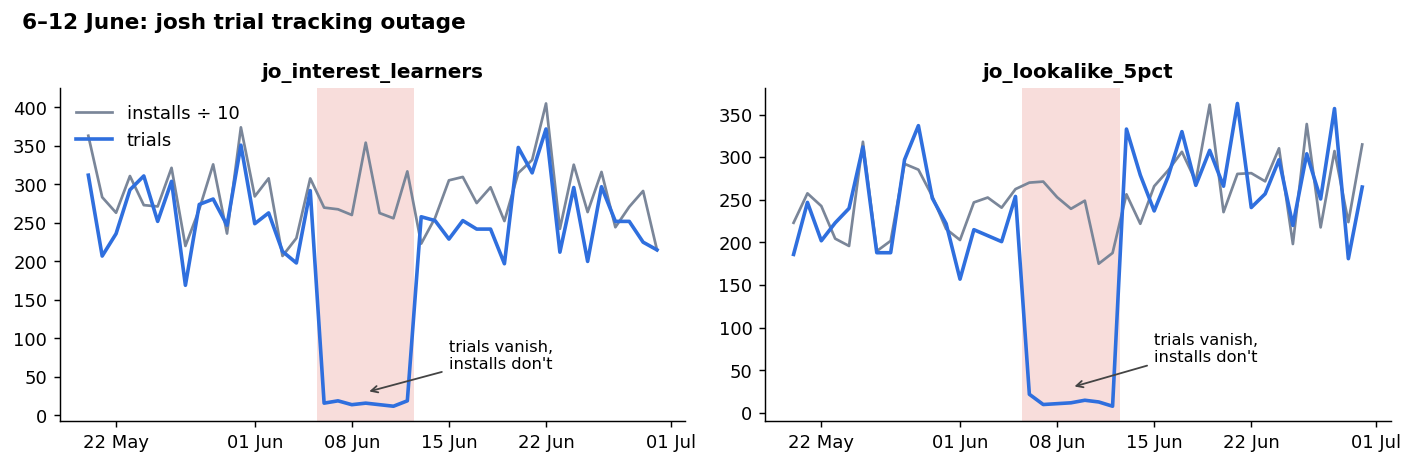

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for ax, camp in zip(axes, jo):
    x = df[(df.campaign == camp) & df.date.between("2026-05-20", "2026-06-30")]
    ax.axvspan(pd.Timestamp("2026-06-05 12:00"), pd.Timestamp("2026-06-12 12:00"), color="#F4C7C3", alpha=.6, lw=0)
    ax.plot(x.date, x.installs / 10, color="#7A8699", lw=1.5, label="installs ÷ 10")
    ax.plot(x.date, x.trials, color="#2F6FDE", lw=2, label="trials")
    ax.set_title(camp, fontsize=11); ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
    ax.annotate("trials vanish,\ninstalls don't", xy=(pd.Timestamp("2026-06-09"), 30), xytext=(pd.Timestamp("2026-06-15"), 60),
                fontsize=9, arrowprops=dict(arrowstyle="->", color="#444"))
axes[0].legend(frameon=False, loc="upper left")
fig.suptitle("6–12 June: josh trial tracking outage", fontweight="bold", x=.02, ha="left")
fig.tight_layout(); fig.savefig(f"{CHARTS}/01_trial_tracking_outage.png", bbox_inches="tight"); plt.show()

**What happened.** From 6 to 12 June, `jo_interest_learners` and `jo_lookalike_5pct` kept spending normally and kept getting their usual installs, but recorded trials fell by about 95%. Renewals and revenue fell with them. Nothing else on josh changed: the third josh campaign (`jo_retarget_signup`) was unaffected, and neither was any other channel. People who install at the normal rate don't suddenly stop starting trials for exactly seven days and then return to normal. This is a tracking outage on the trial event for those two campaigns, not a real drop in demand.

**Why it shows up on 13 June.** On 13 June, tracking was back. The renewals recorded that day belong to the real trials started on 12 June, but the file only recorded 19 and 8 of those trials. So renewals exceed the previous day's trials. 13 June is the symptom; 6–12 June is the cause.

**Rows affected.** 14 rows (7 days × 2 campaigns) have wrong trials, renewals and revenue. Spend, impressions, clicks and installs on those rows are fine.

**How I handle it.** I keep every row and all spend. I flag the 14 rows and exclude affected trial cohorts from conversion and cost-per-user metrics: trial days 5–12 June for these two campaigns (5 June's trials are real, but their renewals were due on 6 June, inside the outage). I don't interpolate, because rebuilding 14 days of trials from averages would feed my own assumptions back into the results.
### 1.4 Failure 2: revenue doesn't match prices (glance, 15–21 July)

In [ ]:
bad_rev = checks["revenue = trials*2 + monthly*249 + annual*1,499"]
x = df.loc[bad_rev, ["date","campaign","revenue_inr","expected_revenue"]].copy()
x["reported ÷ expected"] = (x.revenue_inr / x.expected_revenue).round(4)
x

,date,campaign,revenue_inr,expected_revenue,reported ÷ expected
75,2026-07-15,gl_lockscreen_story,"17,494.68",14826,1.18
76,2026-07-16,gl_lockscreen_story,"17,520.64",14848,1.18
77,2026-07-17,gl_lockscreen_story,"20,555.60",17420,1.18
78,2026-07-18,gl_lockscreen_story,"21,984.58",18631,1.18
79,2026-07-19,gl_lockscreen_story,"21,070.08",17856,1.18
80,2026-07-20,gl_lockscreen_story,"23,034.78",19521,1.18
81,2026-07-21,gl_lockscreen_story,"20,443.50",17325,1.18


Every mismatch is on `gl_lockscreen_story`, 15–21 July, and every one is exactly 1.18 × the expected value. 18% is India's GST rate, and this file is supposed to be ex-GST. So for one week, glance revenue was reported including tax. **Handling:** recompute revenue from trials and renewals for these 7 rows. Leaving them in would overstate glance revenue by ₹21,677 and flatter its ROAS.

In [ ]:
gst_rows = bad_rev
gst_overstatement = (df.loc[gst_rows, "revenue_inr"] - df.loc[gst_rows, "expected_revenue"]).sum()
print(f"GST overstatement: ₹{gst_overstatement:,.0f}")

GST overstatement: ₹21,677


### 1.5 Failure 3: one day of spend at double the normal price (inmobi, 22 May)

In [ ]:
cpm_bad = checks["CPM within 1.6x of campaign median"]
df.loc[cpm_bad | (df.campaign.eq("im_cpi_optimised") & df.date.between("2026-05-20","2026-05-24")),
       ["date","campaign","spend_inr","impressions","installs","cpm","cpm_vs_median"]]

,date,campaign,spend_inr,impressions,installs,cpm,cpm_vs_median
199,2026-05-20,im_cpi_optimised,"69,986.82",1589218,5511,44.04,1.05
200,2026-05-21,im_cpi_optimised,"79,915.06",1992154,8497,40.11,0.96
201,2026-05-22,im_cpi_optimised,"148,314.29",1757455,6263,84.39,2.02
202,2026-05-23,im_cpi_optimised,"81,221.40",1941907,6674,41.83,1.00
203,2026-05-24,im_cpi_optimised,"73,196.14",1648249,6415,44.41,1.06


On 22 May, `im_cpi_optimised` spent about twice its usual amount but got a normal number of impressions, clicks and installs. Its CPM was ₹84 against a usual ₹42. The ratio is almost exactly 2, which looks like the same spend posted twice by a billing sync. **Handling:** halve that one day's spend in the cleaned data and flag it. The effect on campaign totals is small (₹74,157 on a ₹69 lakh campaign), but I'd confirm it against the inmobi invoice before relying on it.

In [ ]:
dbl_excess = df.loc[cpm_bad, "spend_inr"].sum() / 2
print(f"Excess spend: ₹{dbl_excess:,.0f}")

Excess spend: ₹74,157


### 1.6 The cleaned table

In [ ]:
df["flag_outage"] = df.campaign.isin(jo) & df.date.between("2026-06-06", "2026-06-12")
df["flag_gst"] = gst_rows
df["flag_double_spend"] = cpm_bad
df["spend_clean"] = np.where(df.flag_double_spend, df.spend_inr / 2, df.spend_inr)
df["revenue_clean"] = np.where(df.flag_gst, df.expected_revenue, df.revenue_inr)
# cohort view: trials on day d are matched to renewals charged on day d+1
g = df.groupby("campaign")
df["paid_users"] = g.renewals.shift(-1)
df["annual_users"] = g.annual_renewals.shift(-1)
df["cohort_ok"] = df.paid_users.notna() & ~(df.campaign.isin(jo) & df.date.between("2026-06-05", "2026-06-12"))
sub_rev = df.revenue_clean - df.trials * TRIAL_PRICE
refund_rate = df.refunds_inr.groupby(df.campaign).sum() / sub_rev.groupby(df.campaign).sum()
df["cohort_net_revenue"] = (df.trials * TRIAL_PRICE + ((df.paid_users - df.annual_users) * MONTHLY_PRICE
                            + df.annual_users * ANNUAL_PRICE) * (1 - df.campaign.map(refund_rate)))
print("flagged rows:", int(df[["flag_outage","flag_gst","flag_double_spend"]].any(axis=1).sum()),
      "| cohorts used:", int(df.cohort_ok.sum()), "of", len(df))
print("refund rate on subscription revenue:", refund_rate.round(4).to_dict())

flagged rows: 22 | cohorts used: 518 of 540
refund rate on subscription revenue: {'gl_lockscreen_story': 0.0264, 'im_cpa_trial': 0.0249, 'im_cpi_optimised': 0.0262, 'jo_interest_learners': 0.0261, 'jo_lookalike_5pct': 0.0262, 'jo_retarget_signup': 0.0274}


A note on refunds: they're booked on the day they happen, not on the day of the original charge, so they can't be matched to a specific trial day. I use each campaign's refund rate over the whole period (about 2.5–2.7% of subscription revenue) and apply it to each cohort.

### 1.7 What I'd ask an engineer before spending money on this
1. Was trial tracking down for the two josh campaigns on 6–12 June, and can the real trial and renewal counts be recovered from the payments database? If so, I'd replace the flagged rows instead of excluding them.
2. Did glance revenue include GST on 15–21 July, and has the reporting job been fixed?
3. Does the inmobi invoice show ₹1,48,314 or half that for 22 May?
4. Are installs, trials and renewals attributed with the same window and model on every channel? If inmobi counts installs more generously than josh, part of the gap between them is measurement, not performance.
5. Is `renewals` counted when the payment succeeds or when it's attempted? Failed charges would make trial→paid look better than the cash in the bank.

## 2. How does each campaign really perform?
Everything in this section uses cleaned spend and revenue and **trial cohorts**: each day's trials are matched to the renewals charged the next day. The last day (29 July) has no next-day renewals and is excluded; so are the flagged josh cohorts.

In [ ]:
c = df[df.cohort_ok]
k = c.groupby("campaign").agg(spend=("spend_clean","sum"), installs=("installs","sum"), trials=("trials","sum"),
                              paid=("paid_users","sum"), annual=("annual_users","sum"), net=("cohort_net_revenue","sum"))
kpi = pd.DataFrame({
    "channel": CH,
    "cost per install": k.spend / k.installs,
    "cost per trial": k.spend / k.trials,
    "trial→paid %": 100 * k.paid / k.trials,
    "cost per paying user": k.spend / k.paid,
    "annual plan %": 100 * k.annual / k.paid,
    "net 1st-month ROAS": k.net / k.spend,
}).sort_values("cost per paying user")
kpi.round(2)

,channel,cost per install,cost per trial,trial→paid %,cost per paying user,annual plan %,net 1st-month ROAS
campaign,,,,,,,
jo_retarget_signup,josh,16.78,114.74,42.50,269.98,35.73,2.52
jo_lookalike_5pct,josh,18.02,178.43,32.59,547.56,25.43,1.02
gl_lockscreen_story,glance,8.31,146.86,23.32,629.67,10.97,0.61
jo_interest_learners,josh,18.14,197.96,23.78,832.34,14.40,0.51
im_cpi_optimised,inmobi,11.65,200.07,18.89,"1,059.07",13.21,0.39
im_cpa_trial,inmobi,23.43,117.11,9.95,"1,177.22",6.07,0.29


**Why the matching matters.** Two shortcuts are tempting, and both give the wrong answer:
- **Dividing total renewals by total trials over the same days.** This mixes two groups of people. When a campaign's spend is rising, today's trials are larger than yesterday's, so this ratio *understates* conversion; when spend is falling, it overstates it.
- **Averaging each day's renewals ÷ trials.** A day with 150 trials counts as much as a day with 400, and noisy small days push the average up. It overstates conversion on every campaign here.

In this dataset spend moves gradually, so the gaps are small, but the directions are the ones you'd expect: the two fastest-growing campaigns (`im_cpi_optimised`, `jo_lookalike_5pct`) show the largest understatement from same-day totals, and the daily average overstates everywhere by 0.3–1.6 points.

In [ ]:
same_day = df.groupby("campaign").apply(lambda x: 100 * x.renewals.sum() / x.trials.sum(), include_groups=False)
avg_daily = df.groupby("campaign").apply(lambda x: 100 * (x.renewals / x.trials).mean(), include_groups=False)
trend = df.groupby("campaign").apply(lambda x: x.spend_clean.tail(30).mean() / x.spend_clean.head(30).mean() - 1, include_groups=False)
pd.DataFrame({"spend change (first vs last 30 days) %": 100 * trend, "cohort-matched %": kpi["trial→paid %"],
              "same-day totals %": same_day, "average of daily ratios %": avg_daily}).round(2).sort_values("spend change (first vs last 30 days) %")

,spend change (first vs last 30 days) %,cohort-matched %,same-day totals %,average of daily ratios %
campaign,,,,
gl_lockscreen_story,-18.58,23.32,23.30,24.03
jo_retarget_signup,2.59,42.50,42.48,44.06
jo_interest_learners,9.62,23.78,23.74,24.52
im_cpa_trial,15.98,9.95,9.88,10.23
jo_lookalike_5pct,24.56,32.59,32.30,34.02
im_cpi_optimised,29.87,18.89,18.70,19.26


## 3. Do cheap trials always mean cheap paying users?

In [ ]:
rank = pd.DataFrame({"cost per trial": kpi["cost per trial"], "rank by cost per trial": kpi["cost per trial"].rank().astype(int),
                     "cost per paying user": kpi["cost per paying user"], "rank by cost per paying user": kpi["cost per paying user"].rank().astype(int)})
rank.sort_values("rank by cost per trial")

,cost per trial,rank by cost per trial,cost per paying user,rank by cost per paying user
campaign,,,,
jo_retarget_signup,114.74,1,269.98,1
im_cpa_trial,117.11,2,"1,177.22",6
gl_lockscreen_story,146.86,3,629.67,3
jo_lookalike_5pct,178.43,4,547.56,2
jo_interest_learners,197.96,5,832.34,4
im_cpi_optimised,200.07,6,"1,059.07",5


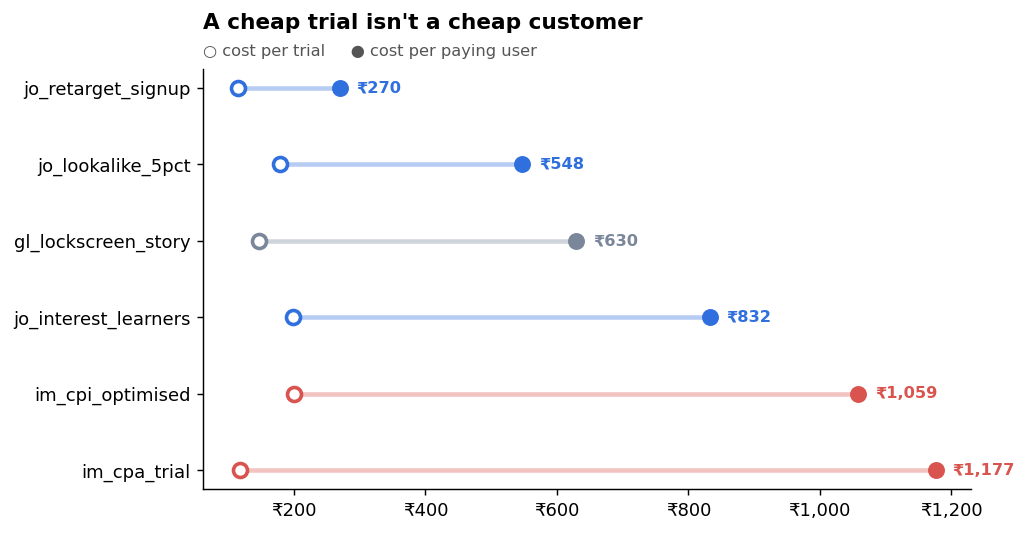

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.2))
order = kpi.sort_values("cost per paying user").index
for i, camp in enumerate(order):
    t, p = kpi.loc[camp, "cost per trial"], kpi.loc[camp, "cost per paying user"]
    colr = COL[CH[camp]]
    ax.plot([t, p], [i, i], color=colr, lw=2.5, alpha=.35)
    ax.scatter(t, i, color="white", edgecolor=colr, s=60, zorder=3, lw=2)
    ax.scatter(p, i, color=colr, s=70, zorder=3)
    ax.text(p + 25, i, f"₹{p:,.0f}", va="center", fontsize=9, color=colr, fontweight="bold")
ax.set_yticks(range(len(order)), order); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mt.FuncFormatter(lambda v, _: f"₹{v:,.0f}"))
ax.set_title("A cheap trial isn't a cheap customer", loc="left", pad=22)
ax.text(0, 1.03, "○ cost per trial     ● cost per paying user", transform=ax.transAxes, fontsize=9, color="#555")
fig.tight_layout(); fig.savefig(f"{CHARTS}/02_cost_per_trial_vs_paying_user.png", bbox_inches="tight"); plt.show()

The two campaigns with the cheapest trials give very different results. `jo_retarget_signup` is cheap at every step. `im_cpa_trial` is cheap only at the trial step.

`im_cpa_trial` is the second-cheapest campaign per trial (₹117) and the most expensive per paying user (₹1,177). It's cheap at the step inmobi's bidding is optimised for, starting a ₹2 trial, and poor at the step Bolo earns from. Only about 1 in 10 of its trials becomes a paying user, against 3 to 4 in 10 on josh lookalike and retargeting, and only 6% of its paying users choose the annual plan. So cheap trials don't always mean cheap customers: judged by what a paying customer costs, it's the worst campaign in the account, and it took 19% of the last 90 days' spend.

The ranking by cost per paying user is also the ranking by net first-month ROAS (section 7), so this isn't an artefact of which metric I picked.
## 4. Where should weekday and weekend spend go?
Days are assigned by **trial day**, and each day's trials are matched to the next day's renewals, so a Saturday trial that pays on Sunday counts as a Saturday result.

In [ ]:
c = df[df.cohort_ok].copy()
c["day_type"] = np.where(c.date.dt.dayofweek >= 5, "weekend", "weekday")
w = c.groupby(["campaign", "day_type"]).agg(spend=("spend_clean","sum"), paid=("paid_users","sum"))
w["cost per paying user"] = w.spend / w.paid
wk = w["cost per paying user"].unstack()
wk["weekend vs weekday %"] = 100 * (wk.weekend / wk.weekday - 1)
wk["channel"] = CH
wk = wk.sort_values("weekend vs weekday %"); wk.round(1)

day_type,weekday,weekend,weekend vs weekday %,channel
campaign,,,,
jo_interest_learners,855.00,787.40,-7.90,josh
jo_lookalike_5pct,556.40,529.90,-4.80,josh
gl_lockscreen_story,629.40,630.30,0.20,glance
im_cpa_trial,"1,124.40","1,312.30",16.70,inmobi
jo_retarget_signup,253.30,312.90,23.50,josh
im_cpi_optimised,989.90,"1,239.50",25.20,inmobi


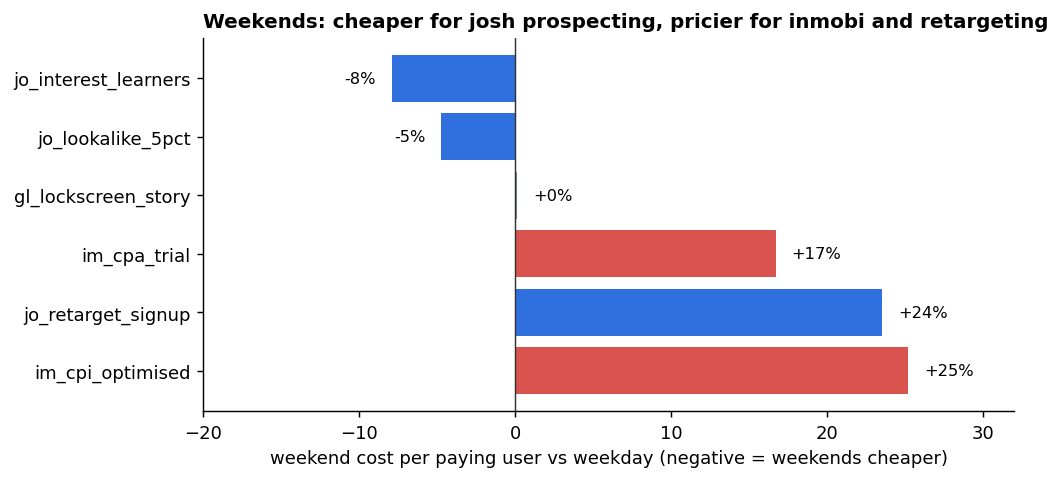

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(wk.index, wk["weekend vs weekday %"], color=[COL[CH[i]] for i in wk.index])
ax.axvline(0, color="#333", lw=.8); ax.invert_yaxis()
for i, v in enumerate(wk["weekend vs weekday %"]):
    ax.text(v + (1 if v >= 0 else -1), i, f"{v:+.0f}%", va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.set_xlabel("weekend cost per paying user vs weekday (negative = weekends cheaper)")
ax.set_title("Weekends: cheaper for josh prospecting, pricier for inmobi and retargeting", loc="left", fontsize=11)
ax.set_xlim(-20, 32)
fig.tight_layout(); fig.savefig(f"{CHARTS}/03_weekday_vs_weekend.png", bbox_inches="tight"); plt.show()

There's no single answer for the whole account. The two josh prospecting campaigns get paying users 5–8% cheaper on weekends, glance is flat, and inmobi and josh retargeting get 17–25% more expensive. Weekend auctions cost more on every channel, but on josh prospecting the extra weekend trials more than make up for it.

**Action:** schedule inmobi and retargeting budgets weekday-heavy and let the two josh prospecting campaigns spend more on Saturdays and Sundays. Each campaign has only about 25 weekend days of history, so I'd run this as a four-week test on one campaign per channel before making it a rule. I've left it out of the budget numbers in section 5 so they don't depend on an untested change.
## 5. How should ₹1 crore be split in August?
### 5.1 Do returns diminish as spend rises?
If they didn't, the answer would be trivial: put everything into the cheapest campaign. First, a simple check with no model: split each campaign's days into its lowest, middle and highest spend thirds and compare cost per paying user.

In [ ]:
c = df[df.cohort_ok].copy()
c["spend level"] = c.groupby("campaign").spend_clean.transform(lambda s: pd.qcut(s, 3, labels=["low","mid","high"]))
t = c.groupby(["campaign","spend level"], observed=True).agg(spend=("spend_clean","sum"), paid=("paid_users","sum"))
terc = (t.spend / t.paid).unstack()
terc["high vs low %"] = 100 * (terc.high / terc["low"] - 1); terc.round(0)

spend level,low,mid,high,high vs low %
campaign,,,,
gl_lockscreen_story,589.00,618.00,674.00,14.00
im_cpa_trial,"1,128.00","1,214.00","1,185.00",5.00
im_cpi_optimised,947.00,"1,003.00","1,208.00",28.00
jo_interest_learners,812.00,838.00,843.00,4.00
jo_lookalike_5pct,522.00,563.00,554.00,6.00
jo_retarget_signup,257.00,266.00,284.00,11.00


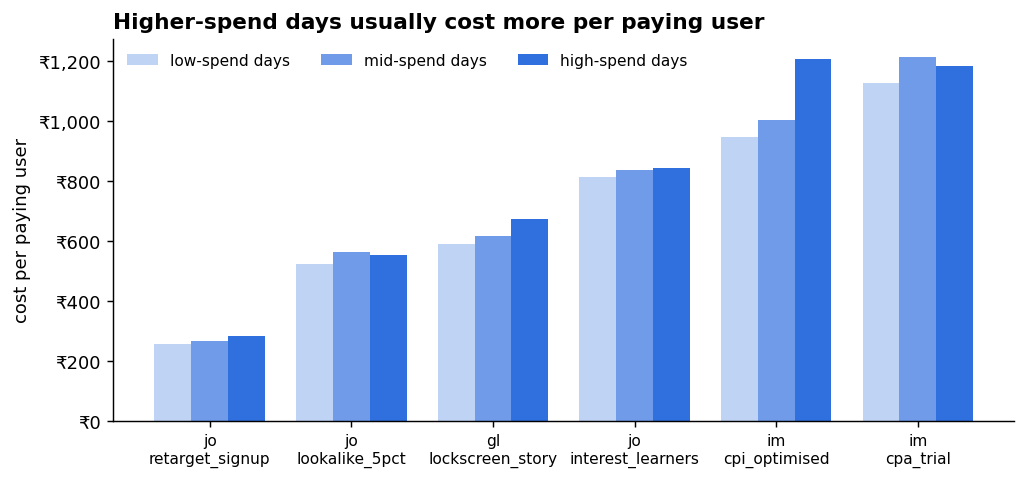

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.8))
t3 = terc.loc[kpi.index, ["low","mid","high"]]
xx = np.arange(len(t3))
for j, (lvl, shade) in enumerate(zip(["low","mid","high"], ["#BFD3F5","#6F9BE8","#2F6FDE"])):
    ax.bar(xx + (j - 1) * .26, t3[lvl], width=.26, color=shade, label=f"{lvl}-spend days")
ax.set_xticks(xx, [s.replace("_", "\n", 1) for s in t3.index], fontsize=8.5)
ax.yaxis.set_major_formatter(mt.FuncFormatter(lambda v, _: f"₹{v:,.0f}"))
ax.set_ylabel("cost per paying user"); ax.legend(frameon=False, fontsize=8.5, ncol=3, loc="upper left")
ax.set_title("Higher-spend days usually cost more per paying user", loc="left")
fig.tight_layout(); fig.savefig(f"{CHARTS}/04_diminishing_returns.png", bbox_inches="tight"); plt.show()

In five of six campaigns, paying users cost more on high-spend days. So I believe in diminishing returns, and the plan assumes it.

To put a number on it, I fit a straight line on the log scale: `log(paying users per day) = campaign constant + b·log(spend per day) + weekend effect`. The slope *b* is the elasticity. At b = 1, doubling spend doubles paying users; at b = 0.74, doubling spend brings about 67% more paying users. This is a regression line.

Fitted campaign by campaign, the slopes are too noisy to use (one comes out above 1, which would mean returns *improve* with scale):

In [ ]:
def fit(x, pooled=False):
    cols = [np.log(x.spend_clean), (x.date.dt.dayofweek >= 5).astype(float)]
    X = np.c_[pd.get_dummies(x.campaign).astype(float).values if pooled else np.ones(len(x)), *cols]
    y = np.log(x.paid_users.clip(lower=1))
    beta = np.linalg.lstsq(X, y, rcond=None)[0]; r = y - X @ beta
    se = np.sqrt(np.diag(r @ r / (len(y) - X.shape[1]) * np.linalg.inv(X.T @ X)))
    return beta[-2], se[-2]
cc = df[df.cohort_ok]
el = pd.DataFrame({camp: fit(x) for camp, x in cc.groupby("campaign")}, index=["b", "std error"]).T
B_SHARED, B_SE = fit(cc, pooled=True)
print(f"shared slope across all campaigns: b = {B_SHARED:.2f} (std error {B_SE:.2f})")
el.round(2)

shared slope across all campaigns: b = 0.74 (std error 0.07)


,b,std error
gl_lockscreen_story,0.34,0.14
im_cpa_trial,1.09,0.18
im_cpi_optimised,0.66,0.13
jo_interest_learners,0.89,0.16
jo_lookalike_5pct,0.74,0.16
jo_retarget_signup,0.87,0.22


With standard errors of 0.13–0.22, the six individual slopes can't be told apart statistically. Fitting one shared slope, with each campaign keeping its own level, gives **b = 0.74 with a standard error of 0.07**. I use that for every campaign, and test 0.55 and 0.90 as the pessimistic and optimistic cases.
### 5.2 The allocation rule
With diminishing returns, the best split is the one where **the next paying user costs the same in every campaign that gets money**. If the next paying user costs ₹900 on one campaign and ₹1,200 on another, moving ₹1,000 from the second to the first buys more users for the same money, so you keep moving until the costs are equal.

Two limits keep the plan inside what the data has actually shown:
- **Tested ceiling:** no campaign is planned above the highest daily spend it has run at in these 90 days. Nothing in the data says what happens beyond that. It matters most for `jo_retarget_signup`, because a retargeting audience is only as big as the pool of people who already installed.
- **Tested floor:** no campaign is planned below the lowest daily spend it has run at. A campaign that would get less than that is switched off instead.

With six campaigns there are only 64 on/off combinations, so I try all of them and keep the one with the most paying users. Each campaign's output is predicted from its own 90-day average, scaled by (planned spend ÷ average spend)^b.

In [ ]:
import itertools
base = cc.groupby("campaign").agg(s0=("spend_clean","mean"), trials0=("trials","mean"), paid0=("paid_users","mean"),
                                   net0=("cohort_net_revenue","mean"), floor=("spend_clean","min"), cap=("spend_clean","max"))
def predict(camp, s, col, b):
    return 0.0 if s <= 0 else base.loc[camp, col] * (s / base.loc[camp, "s0"]) ** b
def allocate(daily_budget, b=None):
    b = B_SHARED if b is None else b
    best = (0, None, None)
    for r_ in range(1, 7):
        for on in map(list, itertools.combinations(base.index, r_)):
            if base.floor[on].sum() > daily_budget or base.cap[on].sum() < daily_budget - 1: continue
            lo, hi = 1.0, 1e6
            for _ in range(80):   # find the marginal cost per paying user that uses up the budget
                lam = (lo + hi) / 2
                s = {k_: np.clip(base.s0[k_] * (lam * b * base.paid0[k_] / base.s0[k_]) ** (1 / (1 - b)),
                                 base.floor[k_], base.cap[k_]) for k_ in on}
                lo, hi = (lam, hi) if sum(s.values()) <= daily_budget else (lo, lam)
            paid = sum(predict(k_, v, "paid0", b) for k_, v in s.items())
            if paid > best[0]: best = (paid, pd.Series(s).reindex(base.index).fillna(0), lam)
    return best[1], best[2]
def plan_table(daily, b=None):
    b = B_SHARED if b is None else b
    t = pd.DataFrame({"channel": CH, "monthly spend": daily * AUG_DAYS})
    t["share %"] = 100 * t["monthly spend"] / t["monthly spend"].sum()
    for col, name in [("trials0","expected trials"), ("paid0","expected paying users"), ("net0","expected 1st-month net revenue")]:
        t[name] = [predict(c_, daily[c_], col, b) * AUG_DAYS for c_ in daily.index]
    t["cost per paying user"] = t["monthly spend"] / t["expected paying users"]
    return t
def total(t):
    s = t[["monthly spend","expected trials","expected paying users","expected 1st-month net revenue"]].sum()
    s["cost per paying user"] = s["monthly spend"] / s["expected paying users"]; return s
fmt = lambda t: t.round({"monthly spend":-3,"share %":1,"expected trials":0,"expected paying users":0,"expected 1st-month net revenue":-3,"cost per paying user":0})
(base[["floor","s0","cap"]] * AUG_DAYS / 1e5).rename(columns={"floor":"tested floor ₹L/month","s0":"90-day average ₹L/month","cap":"tested ceiling ₹L/month"}) \
    .loc[kpi.index].round(1)

,tested floor ₹L/month,90-day average ₹L/month,tested ceiling ₹L/month
campaign,,,
jo_retarget_signup,3.20,4.30,5.70
jo_lookalike_5pct,9.20,14.40,23.30
gl_lockscreen_story,6.50,9.20,13.40
jo_interest_learners,10.40,16.90,23.10
im_cpi_optimised,15.20,24.00,40.30
im_cpa_trial,11.70,16.60,24.30


### 5.3 ₹1 crore: today's split vs the proposed split
"Today's split" means each campaign keeps its share of the last 90 days' spend, scaled up to ₹1 crore.

In [ ]:
share_now = df.groupby("campaign").spend_clean.sum() / df.spend_clean.sum()
daily_prop, marginal = allocate(BUDGET / AUG_DAYS)
current, proposed = plan_table(share_now * BUDGET / AUG_DAYS), plan_table(daily_prop)
print("TODAY'S SPLIT, scaled to ₹1 crore"); display(fmt(current.loc[kpi.index]))
print("PROPOSED"); display(fmt(proposed.loc[kpi.index]))
cmp_ = pd.DataFrame({"today's split": total(current), "proposed": total(proposed)})
cmp_["change"] = cmp_.proposed - cmp_["today's split"]; cmp_["change %"] = 100 * cmp_.change / cmp_["today's split"]
print(f"cost of the last paying user bought in the proposed plan: ₹{marginal:,.0f}")
cmp_.round(1)

TODAY'S SPLIT, scaled to ₹1 crore


,channel,monthly spend,share %,expected trials,expected paying users,expected 1st-month net revenue,cost per paying user
campaign,,,,,,,
jo_retarget_signup,josh,"500,000.00",5.00,"4,185.00","1,779.00","1,212,000.00",281.00
jo_lookalike_5pct,josh,"1,687,000.00",16.90,"9,076.00","2,958.00","1,651,000.00",571.00
gl_lockscreen_story,glance,"1,075,000.00",10.70,"7,029.00","1,639.00","630,000.00",656.00
jo_interest_learners,josh,"1,974,000.00",19.70,"9,574.00","2,277.00","971,000.00",867.00
im_cpi_optimised,inmobi,"2,822,000.00",28.20,"13,524.00","2,555.00","1,057,000.00","1,104.00"
im_cpa_trial,inmobi,"1,942,000.00",19.40,"15,927.00","1,584.00","534,000.00","1,226.00"


PROPOSED


,channel,monthly spend,share %,expected trials,expected paying users,expected 1st-month net revenue,cost per paying user
campaign,,,,,,,
jo_retarget_signup,josh,"572,000.00",5.70,"4,624.00","1,965.00","1,339,000.00",291.00
jo_lookalike_5pct,josh,"2,332,000.00",23.30,"11,537.00","3,759.00","2,098,000.00",620.00
gl_lockscreen_story,glance,"1,336,000.00",13.40,"8,258.00","1,926.00","741,000.00",693.00
jo_interest_learners,josh,"2,310,000.00",23.10,"10,758.00","2,559.00","1,091,000.00",903.00
im_cpi_optimised,inmobi,"2,283,000.00",22.80,"11,558.00","2,183.00","904,000.00","1,046.00"
im_cpa_trial,inmobi,"1,167,000.00",11.70,"10,920.00","1,086.00","366,000.00","1,075.00"


cost of the last paying user bought in the proposed plan: ₹1,411


,today's split,proposed,change,change %
monthly spend,"10,000,000.00","10,000,000.00",-0.00,-0.00
expected trials,"59,315.00","57,653.80","-1,661.20",-2.80
expected paying users,"12,791.90","13,478.90",687.00,5.40
expected 1st-month net revenue,"6,054,572.60","6,537,816.80","483,244.20",8.00
cost per paying user,781.70,741.90,-39.80,-5.10


### 5.4 How much does the answer depend on the slope?

In [ ]:
sens, sens_spend = {}, {}
for label, b in [("pessimistic, b = 0.55", 0.55), (f"shared fit, b = {B_SHARED:.2f}", B_SHARED), ("optimistic, b = 0.90", 0.90)]:
    d, lam = allocate(BUDGET / AUG_DAYS, b)
    cur, pro = total(plan_table(share_now * BUDGET / AUG_DAYS, b)), total(plan_table(d, b))
    sens[label] = {"today's split paying users": cur["expected paying users"], "proposed paying users": pro["expected paying users"],
                   "gain %": 100 * (pro["expected paying users"] / cur["expected paying users"] - 1), "last paying user costs": lam}
    sens_spend[label] = d * AUG_DAYS / 1e5
display(pd.DataFrame(sens).T.round(1))
pd.DataFrame(sens_spend).loc[kpi.index].round(1)

,today's split paying users,proposed paying users,gain %,last paying user costs
"pessimistic, b = 0.55","12,410.60","12,856.20",3.60,"1,863.20"
"shared fit, b = 0.74","12,791.90","13,478.90",5.40,"1,410.60"
"optimistic, b = 0.90","13,117.50","14,043.60",7.10,"1,170.90"


,"pessimistic, b = 0.55","shared fit, b = 0.74","optimistic, b = 0.90"
campaign,,,
jo_retarget_signup,5.70,5.70,5.70
jo_lookalike_5pct,23.30,23.30,23.30
gl_lockscreen_story,13.40,13.40,13.40
jo_interest_learners,23.10,23.10,23.10
im_cpi_optimised,22.30,22.80,22.80
im_cpa_trial,12.20,11.70,11.70


### 5.5 If the budget is cut to ₹60 lakh

In [ ]:
daily_down, marginal_down = allocate(DOWNSIDE / AUG_DAYS)
down = plan_table(daily_down)
display(fmt(down.loc[kpi.index]))
cmp3 = pd.DataFrame({"₹1 crore proposed": total(proposed), "₹60 lakh": total(down)})
cmp3["₹60L as % of ₹1cr"] = 100 * cmp3["₹60 lakh"] / cmp3["₹1 crore proposed"]
print(f"cost of the last paying user bought at ₹60 lakh: ₹{marginal_down:,.0f}")
cmp3.round(1)

,channel,monthly spend,share %,expected trials,expected paying users,expected 1st-month net revenue,cost per paying user
campaign,,,,,,,
jo_retarget_signup,josh,"572,000.00",9.50,"4,624.00","1,965.00","1,339,000.00",291.00
jo_lookalike_5pct,josh,"2,093,000.00",34.90,"10,649.00","3,470.00","1,937,000.00",603.00
gl_lockscreen_story,glance,"780,000.00",13.00,"5,540.00","1,292.00","497,000.00",603.00
jo_interest_learners,josh,"1,039,000.00",17.30,"5,952.00","1,416.00","603,000.00",734.00
im_cpi_optimised,inmobi,"1,515,000.00",25.30,"8,531.00","1,612.00","667,000.00",940.00
im_cpa_trial,inmobi,0.00,0.00,0.00,0.00,0.00,NaN


cost of the last paying user bought at ₹60 lakh: ₹814


,₹1 crore proposed,₹60 lakh,₹60L as % of ₹1cr
monthly spend,"10,000,000.00","6,000,000.00",60.00
expected trials,"57,653.80","35,295.90",61.20
expected paying users,"13,478.90","9,754.70",72.40
expected 1st-month net revenue,"6,537,816.80","5,042,825.80",77.10
cost per paying user,741.90,615.10,82.90


With 40% less money the plan keeps 72% of the paying users, because the cut comes out of the most expensive users first. The order of what to protect: `jo_retarget_signup` stays at its ceiling, `jo_lookalike_5pct` stays near its ceiling, glance and `jo_interest_learners` come down, `im_cpi_optimised` drops to its tested floor, and **`im_cpa_trial` is switched off**.

### 5.6 What the numbers say about `im_cpa_trial`
At ₹1 crore the plan cuts `im_cpa_trial` from ₹19.4 lakh to ₹11.7 lakh, its tested floor, but doesn't switch it off. The reason is that josh and glance are already at their tested ceilings (₹65 lakh together), so the remaining ₹35 lakh has to go to inmobi either way, and spreading it over both inmobi campaigns keeps each in its cheaper range. The first ₹11.7 lakh of `im_cpa_trial` buys paying users at about ₹1,075; putting the same money on top of `im_cpi_optimised` would cost more per user.

So `im_cpa_trial` is the campaign I'd kill, as soon as there's somewhere better to put its money. That happens in two cases: the budget is cut (it goes first at ₹60 lakh), or the josh ceiling test in the recommendation shows josh can take more.

**What would prove me wrong:** if `im_cpa_trial`'s paying users renew into month two and beyond at a much higher rate than josh's. A paying user who stays for a year is worth far more than one who cancels after a month, and this dataset only shows the first charge.

## 6. The recommendation chart

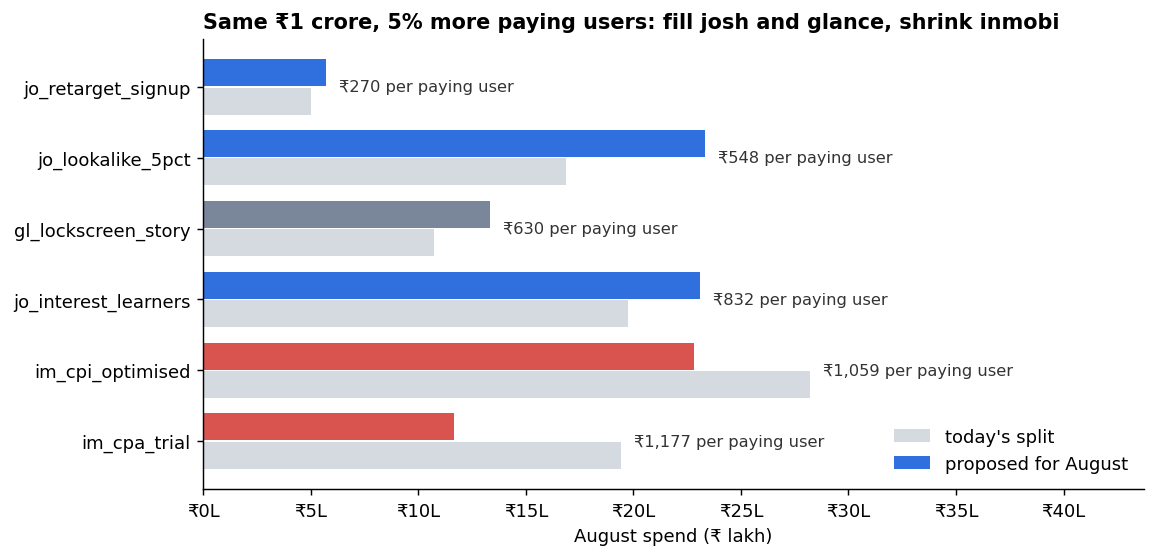

In [ ]:
cur_m, pro_m = current["monthly spend"] / 1e5, proposed["monthly spend"] / 1e5
order = kpi.sort_values("cost per paying user").index
fig, ax = plt.subplots(figsize=(9, 4.4))
y = np.arange(len(order))
ax.barh(y + .2, cur_m[order], height=.38, color="#D5D9E0", label="today's split")
ax.barh(y - .2, pro_m[order], height=.38, color=[COL[CH[c_]] for c_ in order], label="proposed for August")
for i, camp in enumerate(order):
    ax.text(max(cur_m[camp], pro_m[camp]) + .6, i, f"₹{kpi.loc[camp,'cost per paying user']:,.0f} per paying user",
            va="center", fontsize=9, color="#333")
ax.set_yticks(y, order); ax.invert_yaxis(); ax.set_xlim(0, max(cur_m.max(), pro_m.max()) * 1.55)
ax.xaxis.set_major_formatter(mt.FuncFormatter(lambda v, _: f"₹{v:.0f}L"))
ax.set_xlabel("August spend (₹ lakh)")
ax.legend(frameon=False, loc="lower right")
ax.set_title(f"Same ₹1 crore, {cmp_.loc['expected paying users','change %']:.0f}% more paying users: fill josh and glance, shrink inmobi", loc="left", fontsize=11.5)
fig.tight_layout(); fig.savefig(f"{CHARTS}/00_recommendation.png", bbox_inches="tight"); plt.show()

**Fill josh and glance up to the highest spend each has been tested at and cut inmobi from 48% of the budget to 34.5%: the same ₹1 crore buys about 690 more paying users.**

## 7. Which metric should the team steer on every week?

In [ ]:
pd.DataFrame({"rank by cost per paying user": kpi["cost per paying user"].rank().astype(int),
              "rank by net 1st-month ROAS": kpi["net 1st-month ROAS"].rank(ascending=False).astype(int),
              "rank by cost per trial": kpi["cost per trial"].rank().astype(int)})

,rank by cost per paying user,rank by net 1st-month ROAS,rank by cost per trial
campaign,,,
jo_retarget_signup,1,1,1
jo_lookalike_5pct,2,2,4
gl_lockscreen_story,3,3,3
jo_interest_learners,4,4,5
im_cpi_optimised,5,5,6
im_cpa_trial,6,6,2


In [ ]:
c = df[df.cohort_ok].copy(); c["week"] = c.date.dt.to_period("W")
wkly = c.groupby(["campaign","week"]).agg(spend=("spend_clean","sum"), paid=("paid_users","sum"), net=("cohort_net_revenue","sum"))
wkly["cac"] = wkly.spend / wkly.paid; wkly["roas"] = wkly.net / wkly.spend
cv = wkly.groupby("campaign").agg(cac_cv=("cac", lambda s: s.std() / s.mean()), roas_cv=("roas", lambda s: s.std() / s.mean()))
(100 * cv).round(1).rename(columns={"cac_cv":"week-to-week variation, cost per paying user %","roas_cv":"week-to-week variation, net ROAS %"})

,"week-to-week variation, cost per paying user %","week-to-week variation, net ROAS %"
campaign,,
gl_lockscreen_story,12.40,10.80
im_cpa_trial,7.40,13.00
im_cpi_optimised,7.40,8.90
jo_interest_learners,7.40,9.30
jo_lookalike_5pct,13.70,14.90
jo_retarget_signup,8.00,10.20


**Steer on cost per paying user, matched to trial day.** Cost per trial ranks `im_cpa_trial` second-best when it's the worst, so it rewards campaigns for producing trials that never pay. Net first-month ROAS gives exactly the same ranking as cost per paying user here, but it's noisier week to week on five of six campaigns because a handful of ₹1,499 annual plans can swing it. Cost per paying user has one number the team can compare across campaigns, react to within a week, and check against a target; the annual-plan share is worth reviewing monthly alongside it.
## 8. Save results for the report

In [ ]:
out = {"kpi": kpi.round(2).reset_index().to_dict("records"),
       "proposed": proposed.round(2).reset_index().to_dict("records"),
       "current": current.round(2).reset_index().to_dict("records"),
       "downside": down.round(2).reset_index().to_dict("records"),
       "totals": cmp_.round(2).reset_index().to_dict("records"),
       "downside_totals": cmp3.round(2).reset_index().to_dict("records"),
       "sensitivity": pd.DataFrame(sens).T.round(2).reset_index().to_dict("records"),
       "weekend": wk.round(2).reset_index().to_dict("records"),
       "elasticity": el.round(3).reset_index().to_dict("records"), "b_shared": float(B_SHARED), "b_se": float(B_SE), "marginal": float(marginal), "marginal_down": float(marginal_down), "sens_spend": pd.DataFrame(sens_spend).round(2).reset_index().to_dict("records"),
       "checks": check_table.to_dict("records"),
       "gst_overstatement": float(gst_overstatement), "dbl_excess": float(dbl_excess)}
with open("../reports/results.json", "w") as f: json.dump(out, f, indent=1, default=str)
print("saved ../reports/results.json")

saved ../reports/results.json
